In [1]:

import yfinance as yf
import pandas as pd

# Nifty Bank BeES चा ticker symbol (Yahoo Finance वर भारतीय स्टॉक्ससाठी .NS लावावे लागते)
ticker = "BANKBEES.NS"

# २०२० पासून आतापर्यंतचा डेटा फेच करूया
print("Fetching data...")
data = yf.download(ticker, start="2020-01-01", end="2026-05-01")

# डेटा कसा दिसतोय ते पाहण्यासाठी पहिले ५ रोज प्रिंट करूया
print(data.head())

Fetching data...


/tmp/ipykernel_9731/2528836146.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-05-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     BANKBEES.NS BANKBEES.NS BANKBEES.NS BANKBEES.NS BANKBEES.NS
Date                                                                  
2020-01-01  328.309998  330.100006  327.399994  329.200012       18548
2020-01-02  331.929993  332.950012  328.510010  332.950012       31931
2020-01-03  326.540009  330.100006  325.890015  329.149994     1082930
2020-01-06  319.179993  325.179993  318.000000  325.049988      237648
2020-01-07  320.170013  324.799988  318.079987  321.600006     1099389


In [2]:
# yfinance च्या नवीन व्हर्जनमध्ये कॉलम्स MultiIndex असतात, ते आधी सोपे करूया (ticker चं नाव काढूया)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# १. मुव्हिंग ॲव्हरेजेस (Moving Averages) तयार करणे
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_50'] = data['Close'].rolling(window=50).mean()

# २. डेली रिटर्न (Daily Return) - कालच्या तुलनेत आज किती टक्के बदल झाला
data['Daily_Return'] = data['Close'].pct_change()

# ३. टार्गेट व्हेरीएबल (Target Variable) तयार करणे (उद्याची किंमत)
# आजच्या डेटावरून उद्याची किंमत प्रेडिक्ट करायची आहे, म्हणून आपण उद्याची Close प्राईस आजच्या रो (row) समोर आणू.
data['Target'] = data['Close'].shift(-1)

# रोलिंग (५० दिवस) आणि शिफ्ट केल्यामुळे सुरुवातीचे आणि शेवटचे काही रोज रिकामे (NaN) होतात.
# 'Data Cleaning & Handling Nulls' नुसार आपण हे Nulls काढून टाकूया.
df = data.dropna().copy()

print("Feature Engineering पूर्ण झाली!")
print("एकूण रोज (Rows):", len(df))
print(df[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Target']].head())

Feature Engineering पूर्ण झाली!
एकूण रोज (Rows): 1516
Price            Close       MA_10     MA_50  Daily_Return      Target
Date                                                                  
2020-03-12  244.889999  285.603999  311.9228     -0.095078  257.760010
2020-03-13  257.760010  280.637999  310.5118      0.052554  239.970001
2020-03-16  239.970001  274.962999  308.6726     -0.069018  226.350006
2020-03-17  226.350006  268.152998  306.6688     -0.056757  210.119995
2020-03-18  210.119995  259.337999  304.4876     -0.071703  203.570007


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# १. X (Features/इनपुट्स) आणि y (Target/आउटपुट) वेगळे करणे
features = ['Close', 'Open', 'High', 'Low', 'Volume', 'MA_10', 'MA_50', 'Daily_Return']
X = df[features]
y = df['Target']

# २. Train आणि Test Data मध्ये विभागणी (८०% डेटा ट्रेनिंगसाठी, २०% टेस्टिंगसाठी)
# Time Series असल्यामुळे shuffle=False ठेवणे अत्यंत महत्त्वाचे आहे!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"ट्रेनिंगसाठी उपलब्ध रोज (Rows): {X_train.shape[0]}")
print(f"टेस्टिंगसाठी उपलब्ध रोज (Rows): {X_test.shape[0]}")

# ३. मॉडेल निवडणे आणि ट्रेन करणे (Random Forest)
print("\nमॉडेल ट्रेन होत आहे... कृपया थांबा.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("मॉडेल ट्रेनिंग पूर्ण झाले!")

# ४. टेस्ट डेटावर प्रेडिक्शन (अंदाज) करून बघणे
predictions = model.predict(X_test)

# ५. मॉडेलचा अंदाज (Predicted) आणि खरी किंमत (Actual) यांची तुलना करणारा टेबल
results = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': predictions
}, index=X_test.index)

print("\nप्रेडिक्शनचे पहिले ५ निकाल:")
print(results.head())

ट्रेनिंगसाठी उपलब्ध रोज (Rows): 1212
टेस्टिंगसाठी उपलब्ध रोज (Rows): 304

मॉडेल ट्रेन होत आहे... कृपया थांबा.
मॉडेल ट्रेनिंग पूर्ण झाले!

प्रेडिक्शनचे पहिले ५ निकाल:
            Actual_Price  Predicted_Price
Date                                     
2025-02-01    505.839996       508.333597
2025-02-03    513.880005       504.032301
2025-02-04    516.090027       509.255999
2025-02-05    516.989990       516.292490
2025-02-06    514.530029       516.645185


--- मॉडेलचे मूल्यांकन (Regression Metrics) ---
Mean Absolute Error (MAE): ₹34.09 (मॉडेल सरासरी इतक्या रुपयांनी चुकते)
Root Mean Squared Error (RMSE): ₹41.90


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/li

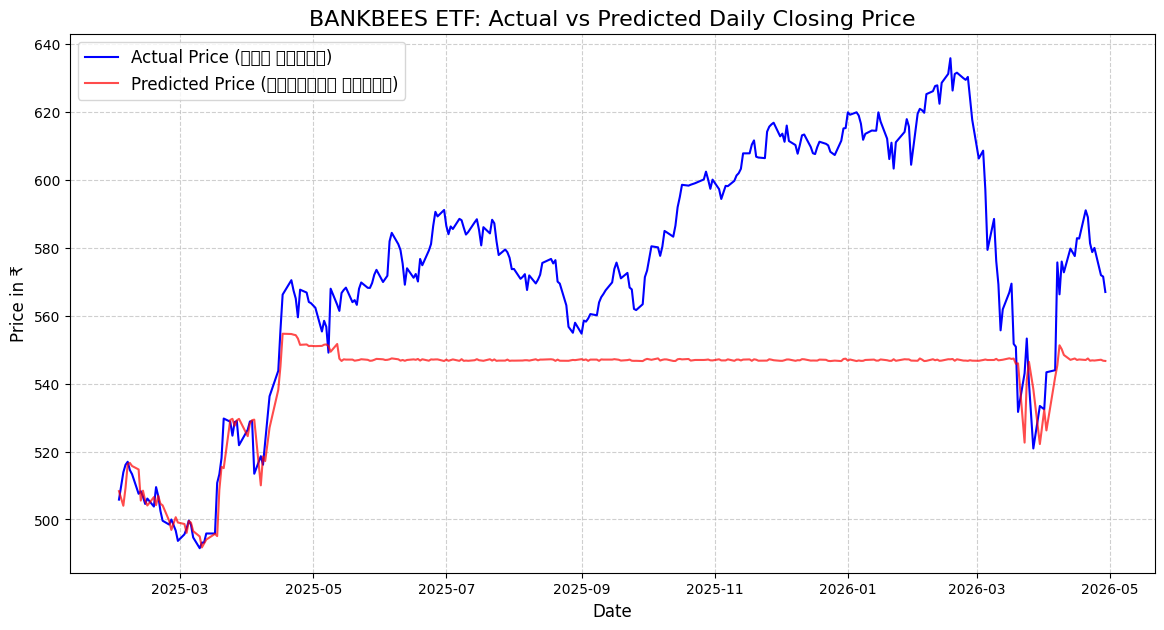

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# १. एरर मेट्रिक्स (Error Metrics) कॅल्क्युलेट करणे
mae = mean_absolute_error(results['Actual_Price'], results['Predicted_Price'])
mse = mean_squared_error(results['Actual_Price'], results['Predicted_Price'])
rmse = np.sqrt(mse)

print("--- मॉडेलचे मूल्यांकन (Regression Metrics) ---")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f} (मॉडेल सरासरी इतक्या रुपयांनी चुकते)")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")

# २. रिझल्ट्सचा ग्राफ (Plot) तयार करणे
plt.figure(figsize=(14, 7))

# खऱ्या किंमतीची निळी रेषा
plt.plot(results.index, results['Actual_Price'], label='Actual Price (खरी किंमत)', color='blue')

# मॉडेलने प्रेडिक्ट केलेल्या किंमतीची लाल रेषा
plt.plot(results.index, results['Predicted_Price'], label='Predicted Price (अंदाजित किंमत)', color='red', alpha=0.7)

# ग्राफला नाव आणि लेबल्स देणे
plt.title('BANKBEES ETF: Actual vs Predicted Daily Closing Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in ₹', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# ग्राफ दाखवणे
plt.show()

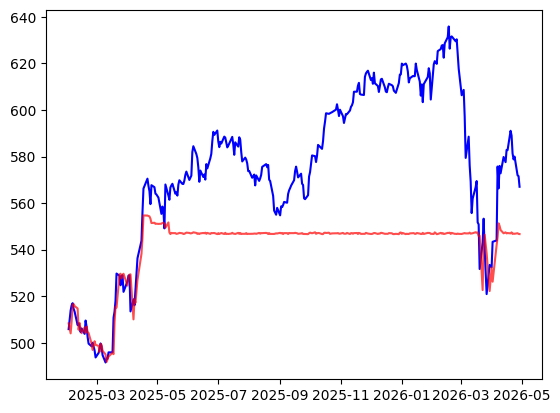

In [5]:
# खऱ्या किंमतीची निळी रेषा (मराठी शब्द काढले)
plt.plot(results.index, results['Actual_Price'], label='Actual Price', color='blue')

# मॉडेलने प्रेडिक्ट केलेल्या किंमतीची लाल रेषा (मराठी शब्द काढले)
plt.plot(results.index, results['Predicted_Price'], label='Predicted Price', color='red', alpha=0.7)